# Atividade Prática — Aula 1  
## Python para Análise de Dados: do dado bruto à decisão estratégica

Nesta atividade, você vai aplicar os conceitos apresentados na aula usando um dataset simulado de vendas no varejo brasileiro.

**Arquivo de dados:** `vendas_brasil_aula1.csv`  
**Objetivo:** praticar leitura de dados, inspeção inicial, qualidade dos dados, KPIs e escolha de visualizações.

---
### O que você vai treinar
- Entender o pipeline básico de análise
- Inspecionar um dataset com `pandas`
- Identificar problemas de qualidade de dados
- Definir KPIs de negócio
- Escolher gráficos adequados para responder perguntas do gestor

## Instruções
1. Faça upload do arquivo `vendas_brasil_aula1.csv` no Google Colab ou deixe-o na mesma pasta do notebook.
2. Execute as células na ordem.
3. Responda às perguntas **no próprio notebook**, em células de texto ou código.
4. Sempre que possível, explique **o que o resultado significa para o negócio**.

## Dataset utilizado

O arquivo contém registros de vendas com as seguintes colunas:

- `Data_Venda`: data da venda
- `Canal_Venda`: canal comercial
- `UF`: estado da venda
- `Produto`: produto vendido
- `Preco_Unitario`: preço unitário
- `Quantidade`: quantidade vendida
- `Custo_Unitario`: custo unitário do item
- `Receita`: valor total da venda
- `Lucro`: lucro total da venda

> Atenção: o dataset foi preparado com **alguns problemas de qualidade propositalmente**, para que você pratique inspeção e limpeza.

## 1) Preparação do ambiente
Execute a célula abaixo para importar a biblioteca principal da atividade.

In [1]:
import pandas as pd

## 2) Leitura do arquivo
Altere o caminho do arquivo, se necessário.

In [2]:
df = pd.read_csv("vendas_brasil_aula1.csv")
df.head()

,Data_Venda,Canal_Venda,UF,Produto,Preco_Unitario,Quantidade,Custo_Unitario,Receita,Lucro
0,2025-04-13,Loja Física,SP,Smartphone,2484.58,3,1872.49,7453.74,1836.27
1,2025-06-29,Loja Física,RJ,Smartwatch,1041.91,1,699.66,1041.91,342.25
2,2025-04-03,E-commerce,RJ,Smartphone,2447.07,1,2077.09,2447.07,369.98
3,2025-01-15,Loja Física,MG,Smartphone,2307.40,1,1797.67,2307.40,509.73
4,2025-04-17,E-commerce,PR,Notebook,3840.18,4,3069.45,15360.72,3082.92


## 3) Atividade 1 — Entendendo o dataset

Responda às perguntas abaixo usando código:

1. Quantas linhas e colunas existem no dataset?
2. Quais são os nomes das colunas?
3. Quais são os tipos de dados de cada coluna?

> Dica: use `shape`, `columns` e `info()`.

In [19]:
df.shape



(300, 9)

In [23]:
df.columns  #'Data_Venda', 'Canal_Venda', 'UF', 'Produto', 'Preco_Unitario', 'Quantidade', 'Custo_Unitario', 'Receita', 'Lucro'

Index(['Data_Venda', 'Canal_Venda', 'UF', 'Produto', 'Preco_Unitario',
       'Quantidade', 'Custo_Unitario', 'Receita', 'Lucro'],
      dtype='object')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Data_Venda      300 non-null    object 
 1   Canal_Venda     293 non-null    object 
 2   UF              294 non-null    object 
 3   Produto         300 non-null    object 
 4   Preco_Unitario  295 non-null    float64
 5   Quantidade      300 non-null    int64  
 6   Custo_Unitario  300 non-null    float64
 7   Receita         300 non-null    float64
 8   Lucro           300 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 21.2+ KB


## 4) Atividade 2 — Qualidade dos dados

Agora investigue se existem problemas de qualidade.

Responda:

1. Existem valores nulos?
2. Em quais colunas eles aparecem?
3. Existem categorias escritas de formas diferentes para o mesmo canal de venda?

> Dica: use `isnull().sum()` e `value_counts()`.

In [26]:
df.isnull().sum() #Sim, as colunas são: Canal_Venda, UF e Preco_Unitario

,0
Data_Venda,0
Canal_Venda,7
UF,6
Produto,0
Preco_Unitario,5
Quantidade,0
Custo_Unitario,0
Receita,0
Lucro,0


In [28]:
df.value_counts() #Sim, existem categorias iguais com o mesmo nome

Data_Venda  Canal_Venda  UF  Produto           Preco_Unitario  Quantidade  Custo_Unitario  Receita  Lucro  
2025-06-29  Marketplace  ES  Smartphone        2749.22         1           1806.41         2749.22  942.81     1
2025-01-02  E-commerce   PE  Fone Bluetooth    353.68          1           180.33          353.68   173.35     1
                         RJ  Smartphone        2962.93         1           1971.27         2962.93  991.66     1
            Marketplace  ES  Notebook          4315.46         1           3301.06         4315.46  1014.40    1
            WhatsApp     PE  Notebook          4304.46         1           3611.50         4304.46  692.96     1
                                                                                                              ..
2025-01-12  E-commerce   RJ  Smartphone        2477.53         2           1811.47         4955.06  1332.12    1
2025-01-11  loja fisica  BA  Teclado Mecânico  389.45          2           186.80          778.90   405.30     1
2025-01-09  loja fisica  SP  Smartwatch        1017.19         1           622.49          1017.19  394.70     1
            Loja Física  RJ  Smartphone        2456.46         2           1925.74         4912.92  1061.44    1
                         BA  Monitor           1010.21         1           696.27          1010.21  313.94     1
Name: count, Length: 282, dtype: int64

## 5) Atividade 3 — KPIs do negócio

Considere que você é analista de um varejista e precisa apresentar indicadores para a gestão.

Calcule os seguintes KPIs:

1. **Receita total**
2. **Lucro total**
3. **Ticket médio** (`Receita média por registro`)
4. **Quantidade total vendida**

Depois, escreva uma breve interpretação:
- O desempenho geral parece positivo?
- Receita e lucro caminham juntos?

In [45]:
df['Receita'].sum()


np.float64(707535.36)

In [46]:
df['Lucro'].sum()


np.float64(189625.88)

In [47]:
df['Receita'].mean()

np.float64(2358.4512)

In [48]:
df['Quantidade'].sum()

np.int64(502)

O desempenho parece positivo, tendo em vista o lucro total da empresa. A receita e o lucro caminham juntos em uma crescente positiva, entretanto é notória a razão entre as duas quando se vê o valor total das duas.

## 6) Atividade 4 — Respondendo perguntas do gestor com dados

Use o dataset para responder:

1. **Qual canal gera mais receita?**
2. **Qual produto gera mais lucro?**
3. **Quais UFs concentram maior receita?**

Para cada resposta:
- mostre o código;
- apresente o resultado;
- escreva uma interpretação curta.

In [67]:
df.groupby('Canal_Venda')['Receita'].sum() # E-Commerce

,Receita
Canal_Venda,
E-commerce,220215.54
Loja Física,216644.15
Marketplace,111659.78
WhatsApp,85974.51
e-commerce,29122.47
loja fisica,19001.16


In [73]:
df.groupby('Produto')['Lucro'].sum() #Fone Bluetooth

,Produto,Lucro
0,Fone Bluetooth,11647.92
1,Monitor,18290.52
2,Mouse Gamer,7324.88
3,Notebook,69818.57
4,Smartphone,31718.11
5,Smartwatch,17029.45
6,Tablet,20936.95
7,Teclado Mecânico,12859.48


In [78]:
resultado = df.groupby('UF')['Receita'].sum()
resultado.sort_values(ascending=False)
# SP, MG e RJ

,Receita
UF,
SP,133727.80
MG,103438.61
RJ,100284.68
PR,69287.74
SC,63740.20
RS,51020.06
ES,50338.64
BA,46765.01
PE,42895.39


## 7) Atividade 5 — Escolhendo a visualização certa

Sem necessariamente construir os gráficos ainda, responda:

a) Qual gráfico você usaria para mostrar a **evolução da receita ao longo do tempo**?  
b) Qual gráfico você usaria para **comparar a receita entre canais de venda**?  
c) Qual gráfico você usaria para mostrar a **distribuição dos preços unitários**?

Em seguida, gere **ao menos um gráfico** com `pandas` ou `matplotlib`.

A- Gráfico de Linha
B- Gráfico de Tabelas Horizontal
C- Gráfico de Pizza

<Axes: xlabel='Canal_Venda'>

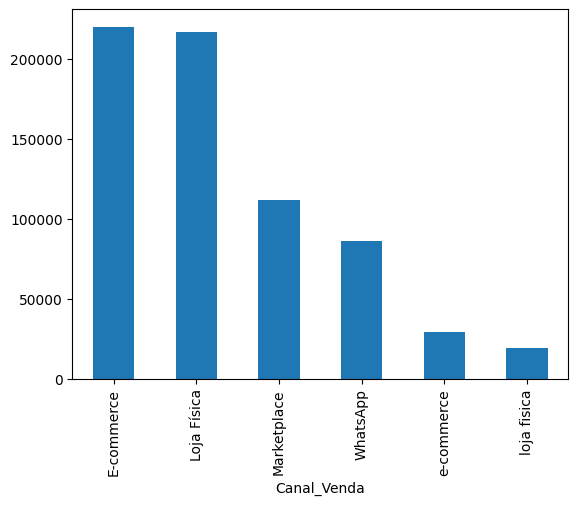

In [81]:
exemplo = df.groupby('Canal_Venda')['Receita'].sum()
exemplo.plot(kind='bar')

## Desafio extra (opcional)

Faça uma pequena limpeza no dataset:

- trate valores nulos;
- padronize os nomes dos canais de venda;
- converta `Data_Venda` para formato de data.

Depois, compare os resultados **antes e depois da limpeza**.

In [86]:
df['Canal_Venda'] = df['Canal_Venda'].str.title()
df['Canal_Venda'].value_counts()


,0
Data_Venda,0
Canal_Venda,0
UF,0
Produto,0
Preco_Unitario,0
Quantidade,0
Custo_Unitario,0
Receita,0
Lucro,0


In [90]:
df['Data_Venda'] = pd.to_datetime(df['Data_Venda'], errors='coerce')
df['Data_Venda']

,Data_Venda
0,2025-04-13
1,2025-06-29
2,2025-04-03
3,2025-01-15
4,2025-04-17
...,...
295,2025-06-25
296,2025-04-25
297,2025-04-29
298,2025-01-22


In [87]:
df.isnull().sum()
df.dropna(inplace=True)
df.isnull().sum()

,0
Data_Venda,0
Canal_Venda,0
UF,0
Produto,0
Preco_Unitario,0
Quantidade,0
Custo_Unitario,0
Receita,0
Lucro,0


## Entrega esperada

Ao final, seu notebook deve conter:

- leitura do dataset;
- inspeção inicial;
- análise de qualidade dos dados;
- cálculo de KPIs;
- respostas às perguntas de negócio;
- pelo menos um gráfico;
- comentários interpretando os resultados.

---
### Reflexão final
Explique em 4 a 6 linhas:

**Por que uma análise de dados não deve se limitar a “fazer gráficos bonitos”?**